In [72]:
import sys
import  os

import numpy as np
import pandas as pd
from io import StringIO
import graphviz
import lingam
from lingam.utils import make_dot, make_prior_knowledge
from causallearn.search.ConstraintBased.FCI import fci
from causallearn.utils.GraphUtils import GraphUtils
from copy import  deepcopy
from scipy import stats
from causallearn.utils.cit import CIT
from sklearn.cluster import KMeans
import json 
from itertools import combinations

### cellA

In [73]:
# ==========================================
# 新 Cell A: 特征对齐与真实样本维度扩展
# ==========================================
import sys
import os
import json
import time
import numpy as np
import pandas as pd
from tqdm import tqdm
from concurrent.futures import ThreadPoolExecutor, as_completed
from openai import OpenAI
from copy import deepcopy

# 配置大模型 API
API_KEY = "70DR6FC7UMPN3896DKWAJKNEIKMCTCJRYJ7ZQX1X"
BASE_URL = "https://ai.gitee.com/v1"

# 1. 强制要求保留的 Excel 维度 (全部统一为小写，防止大小写冲突)
excel_core_features = ['nutrition', 'size', 'smell', 'taste', 'juiciness', 'recmd']

# 2. 读取 LLM 生成的 JSONL 数据
df_llm = pd.read_json("LLM_Dynamic_Apple_Dataset.jsonl", lines=True)
# 将 factors 字典展开，并将所有列名转为小写
df_llm_factors = pd.json_normalize(df_llm['factors']).fillna(0)
df_llm_factors.columns = [c.lower() for c in df_llm_factors.columns]

# 找出 LLM 数据中出现频率最高的特征，补齐剩下的 6 个位置，凑够 12 个 Factor
feature_freq = (df_llm_factors != 0).sum().sort_values(ascending=False)
additional_features = []
for f in feature_freq.index:
    if f not in excel_core_features:
        additional_features.append(f)
    if len(additional_features) == 6: # 取前 6 个
        break

# 最终的 12 个 Factor
selected_features = excel_core_features + additional_features
print(f"全局对齐的 12 个特征维度: {selected_features}")

# 3. 读取 Excel 数据
df_real = pd.read_excel('./Apple_Gastronome_AG7_v20240513.xlsx')

def extract_missing_factors(review_text, target_factors):
    prompt = f"""
    阅读以下苹果试吃评论，提取指定维度的情感得分。
    评论内容："{review_text}"
    需要提取的维度：{target_factors}
    打分规则：-1（负面/差）、0（未提及/中性）、1（正面/好）。
    请严格仅输出JSON格式的字典，键为维度名，值为得分：
    """
    try:
        client = OpenAI(api_key=API_KEY, base_url=BASE_URL)
        response = client.chat.completions.create(
            model="Qwen3-32B",
            messages=[{"role": "user", "content": prompt}],
            temperature=0.1
        )
        content = response.choices[0].message.content.strip()
        if content.startswith("```json"): content = content[7:-3].strip()
        elif content.startswith("```"): content = content[3:-3].strip()
        return json.loads(content.lower())
    except Exception:
        return {f: 0 for f in target_factors}


def extract_factors_for_row(row):
    current_factors = {k: row[k] for k in excel_core_features}
    missing_factors = extract_missing_factors(row['Review'], additional_features)
    combined = {**current_factors, **missing_factors}
    return {k: combined.get(k, 0) for k in selected_features}

# 对 Excel 样本进行维度扩展缓存
REAL_EXTRACTED_FILE = 'Real_Apple_12Dim_Expanded.jsonl'
real_factors_list = []

if os.path.exists(REAL_EXTRACTED_FILE):
    with open(REAL_EXTRACTED_FILE, 'r', encoding='utf-8') as f:
        real_factors_list = [json.loads(line) for line in f]
    print("已加载缓存的 Excel 样本扩展维度。")
else:
    print("正在使用 LLM 补全 Excel 样本缺失的维度...")
    df_real_records = df_real.to_dict('records')
    max_workers = min(32, len(df_real_records))
    futures = []
    with ThreadPoolExecutor(max_workers=max_workers) as executor:
        futures = [executor.submit(extract_factors_for_row, row) for row in df_real_records]
        with open(REAL_EXTRACTED_FILE, 'w', encoding='utf-8') as f:
            for future in tqdm(as_completed(futures), total=len(futures)):
                final_factors = future.result()
                f.write(json.dumps(final_factors, ensure_ascii=False) + '\n')
                real_factors_list.append(final_factors)


# 如果缓存或新生成结果都可用，则继续构造 DataFrame
df_real_expanded = pd.DataFrame(real_factors_list)[selected_features] # 保证列顺序一致

全局对齐的 12 个特征维度: ['nutrition', 'size', 'smell', 'taste', 'juiciness', 'recmd', 'crispness', 'price', 'packaging', 'location', 'sweetness', 'mood']
已加载缓存的 Excel 样本扩展维度。


### cellB

In [74]:
# ==========================================
# 新 Cell B: 数据混合、过采样与神经网络训练
# ==========================================
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

for feature in selected_features:
    if feature not in df_llm_factors.columns:
        df_llm_factors[feature] = 0

# 1. 整理 LLM 的 X 和 Y
X_llm = df_llm_factors[selected_features].copy()
Y_llm = df_llm['score'].copy()
df_train_llm = pd.concat([Y_llm, X_llm], axis=1)

# 2. 整理扩展后的 Excel 数据，随机抽 50 条并放大 20 倍 (50 * 20 = 1000)
Y_real = df_real['score'].copy()
df_train_real_full = pd.concat([Y_real, df_real_expanded], axis=1)

np.random.seed(42)
sampled_indices = np.random.choice(df_train_real_full.index, 50, replace=False)
df_real_50 = df_train_real_full.loc[sampled_indices]
df_real_weighted = pd.concat([df_real_50] * 20, ignore_index=True)

# 3. 终极混合训练集 (大概 2000 条左右)
df_mixed = pd.concat([df_train_llm, df_real_weighted], ignore_index=True)
df_mixed = df_mixed.sample(frac=1, random_state=42).reset_index(drop=True) # 打乱

X_train = df_mixed[selected_features].values.astype(np.float32)
Y_train = df_mixed['score'].values.astype(np.float32).reshape(-1, 1)

train_loader = DataLoader(TensorDataset(torch.tensor(X_train), torch.tensor(Y_train)), batch_size=32, shuffle=True)

# 4. 构建神经网络
class NeuralScorer(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 32),
            nn.LeakyReLU(0.2), 
            nn.Linear(32, 16),
            nn.LeakyReLU(0.2),
            nn.Linear(16, 1)
        )
    def forward(self, x):
        return self.net(x)

nn_model = NeuralScorer(len(selected_features))
optimizer = optim.Adam(nn_model.parameters(), lr=0.005)
criterion = nn.MSELoss()

print(f"开始训练 Neural Scorer (总样本量: {len(df_mixed)})...")
nn_model.train()
for epoch in range(60):
    for batch_x, batch_y in train_loader:
        optimizer.zero_grad()
        loss = criterion(nn_model(batch_x), batch_y)
        loss.backward()
        optimizer.step()

print(f"训练完成！最终 MSE Loss: {loss.item():.4f}")

开始训练 Neural Scorer (总样本量: 2000)...
训练完成！最终 MSE Loss: 0.1710


### cellC

In [75]:
# ==========================================
# 新 Cell C: 重构 meta 与 values，无缝对接 COAT 框架
# ==========================================

# 1. 提取完整的 200 条 Excel 真实扩展特征
X_eval = df_real_expanded[selected_features].values.astype(np.float32)

# 2. 神经网络重新打分
nn_model.eval()
with torch.no_grad():
    NN_scores = nn_model(torch.tensor(X_eval)).numpy().squeeze()

# 3. 分数离散化 (完美匹配原数据集大致的 -3 到 3 的分布)
# 用 7 个区间切分，确保分类均衡
NN_scores_discrete = pd.qcut(NN_scores, q=7, labels=[-3, -2, -1, 0, 1, 2, 3], duplicates='drop').to_numpy(dtype=float)

# 4. 重构 meta DataFrame
# 严格按照要求：score 必须在第 0 列，接着是 12 个 Factor，最后一列是文本 Review
meta = pd.DataFrame({'score': NN_scores_discrete})

# 插入 12 个特征维度
for factor in selected_features:
    meta[factor] = df_real_expanded[factor].values

# 插入原本的 Review 文本 (供后续代码去找 high entropy 样本提词用)
meta['Review'] = df_real['Review'].values

# 5. 生成原框架要求的 values 和 names (剔除最后一列 Review 文本)
values = meta.values[:, :-1].astype(float)
names = list(meta.columns[:-1])

print("\n=== 数据重构完成，神经网络已成功接管因果检验输入！ ===")
print(f"meta 数据维度: {meta.shape} (1个Score + 12个Factor + 1个Review)")
print(f"values 矩阵维度: {values.shape}")
meta.head()


=== 数据重构完成，神经网络已成功接管因果检验输入！ ===
meta 数据维度: (200, 14) (1个Score + 12个Factor + 1个Review)
values 矩阵维度: (200, 13)


,score,nutrition,size,smell,taste,juiciness,recmd,crispness,price,packaging,location,sweetness,mood,Review
0,3.0,-1,1,1,0,0,0,0,0,0,0,0,0,The assessed apple falls short in offering th...
1,2.0,-1,1,1,1,0,1,0,0,0,0,1,1,This apple's profile—rich in essential nutrie...
2,0.0,1,1,1,0,0,1,0,0,0,0,0,1,Despite the comparatively modest nutrient pro...
3,1.0,1,-1,1,-1,1,1,0,0,0,0,-1,0,Despite its large size and appealing sweetnes...
4,0.0,1,-1,-1,1,1,0,0,0,0,0,1,0,Despite its impressive profile packed with di...


### cellD

⚠️ 警告: 发现无效常数特征 'packaging' (所有样本的值都相同)，已自动剔除！
⚠️ 警告: 发现无效常数特征 'location' (所有样本的值都相同)，已自动剔除！

参与全局因果推断的节点总数: 11
节点列表: ['score', 'nutrition', 'size', 'smell', 'taste', 'juiciness', 'recmd', 'crispness', 'price', 'sweetness', 'mood']

正在运行 FCI 算法探测全局因果网络 (使用 chisq 离散检验，瞬间完成)...


  0%|          | 0/11 [00:00<?, ?it/s]


直接决定 Neural Scorer 打分的因果变量 (马尔可夫毯) 有: 
{'juiciness', 'score', 'size', 'nutrition', 'crispness', 'recmd', 'mood'}


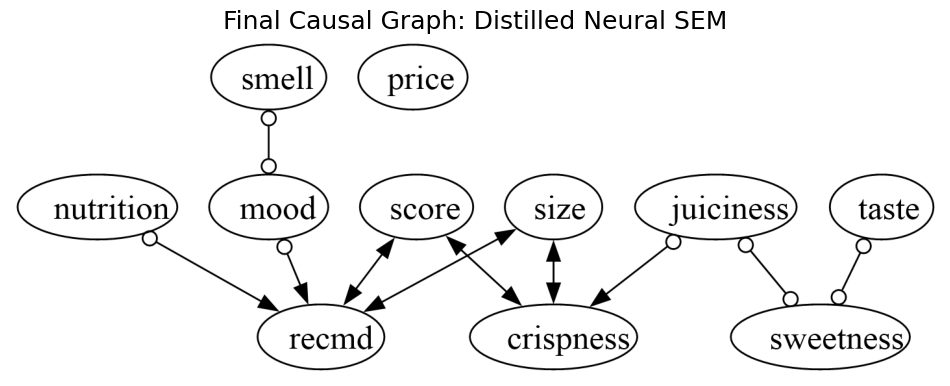


=== 全局因果图绘制完成 ===


In [76]:
# ==========================================
# Cell 4: 终局之战 - 全局 Neural SEM 因果图发现 (稳定版)
# ==========================================
import warnings
warnings.filterwarnings('ignore') # 屏蔽底层的除零警告骚扰

from causallearn.search.ConstraintBased.FCI import fci
from causallearn.utils.GraphUtils import GraphUtils
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import numpy as np

# 1. 常数列排雷：如果某个特征在所有样本里值都一样，因果算法会崩溃，必须剔除
valid_columns = []
for col in meta.columns[:-1]: # 不看最后一列 Review
    if len(meta[col].unique()) > 1:
        valid_columns.append(col)
    else:
        print(f"⚠️ 警告: 发现无效常数特征 '{col}' (所有样本的值都相同)，已自动剔除！")

# 2. 提取有效因子名和矩阵
target_name = 'score'
annotated_name = [target_name] + [f for f in valid_columns if f != target_name]

# 确保 values 矩阵的列顺序与 annotated_name 完全对应
annoted_values = meta[annotated_name].values.astype(float)

# --- 引入原作者的马尔可夫毯提取工具 ---
def GetMB(G, node_names, y_node=0):
    mbset = set([y_node])
    d = G.shape[0]
    get_direct_set = lambda x: set([idx for idx in range(d) if np.abs(G[x, idx]) + np.abs(G[idx, x]) > 0])
    direct_set = get_direct_set(y_node)
    mbset = mbset.union(direct_set)
    for idx in direct_set:
        if G[idx, y_node ] == -1: continue
        for each_secondary in get_direct_set(idx):
            if G[idx, each_secondary] == -1: continue
            mbset.add(each_secondary)
    return set([node_names[i] for i in mbset])
# --------------------------------------

print(f"\n参与全局因果推断的节点总数: {len(annotated_name)}")
print(f"节点列表: {annotated_name}")

# 3. 运行 FCI 算法探测复杂因果网络
print("\n正在运行 FCI 算法探测全局因果网络 (使用 chisq 离散检验，瞬间完成)...")
# 【核心修复】：将独立性检验方法从容易除零的 kci 换成了适合离散数据的 chisq (卡方检验)
g, edges = fci(annoted_values, alpha=0.05, independence_test_method='chisq', verbose=False)

# 4. 找出直接影响神经网络打分的马尔可夫毯 (Markov Blanket)
new_V = GetMB(g.graph, annotated_name, y_node=0)
print(f"\n直接决定 Neural Scorer 打分的因果变量 (马尔可夫毯) 有: \n{new_V}")

# 5. 可视化最终的复杂因果网络
output_img_name = 'Final_Neural_Causal_Graph_Global.png'
pdy = GraphUtils.to_pydot(g, labels=annotated_name)
pdy.write_png(output_img_name)

# 在 Jupyter 中展示图片
plt.figure(figsize=(12, 12))
img = mpimg.imread(output_img_name)
plt.imshow(img)
plt.axis('off')
plt.title("Final Causal Graph: Distilled Neural SEM", fontsize=18)
plt.show()

print("\n=== 全局因果图绘制完成 ===")